# TP 05 — CNN

In [23]:
"""
TP 05 — CNN
Objectif : comprendre et construire un réseau convolutionnel.
Dataset : digits de Scikit-Learn (images 8x8).
"""

'\nTP 05 — CNN\nObjectif : comprendre et construire un réseau convolutionnel.\nDataset : digits de Scikit-Learn (images 8x8).\n'

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [25]:
digits = load_digits()

In [26]:
X = digits.images.astype("float32") / 16.0
y = digits.target

In [27]:
print(X.shape)

(1797, 8, 8)


In [28]:
# Ajouter la cana; : (N, 8, 8) -> (N, 8, 8, 1)
X = X[..., np.newaxis]

In [29]:
print(X.shape)

(1797, 8, 8, 1)


In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [31]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(8, 8, 1)),
    
    tf.keras.layers.Conv2D(16, kernel_size=3, activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, kernel_size=3, activation="relu", padding="same"),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [32]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 16)       │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,282 (149.54 KB)

 Trainable params: 38,282 (149.54 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [34]:
model.fit(X_train, y_train, epochs=25, batch_size=32, validation_split=0.2)

Epoch 1/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.4421 - loss: 2.0587 - val_accuracy: 0.6562 - val_loss: 1.6844
Epoch 2/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8172 - loss: 1.0318 - val_accuracy: 0.8333 - val_loss: 0.6652
Epoch 3/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9104 - loss: 0.3902 - val_accuracy: 0.8958 - val_loss: 0.3900
Epoch 4/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9460 - loss: 0.2332 - val_accuracy: 0.9028 - val_loss: 0.3031
Epoch 5/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9556 - loss: 0.1776 - val_accuracy: 0.9132 - val_loss: 0.2847
Epoch 6/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9617 - loss: 0.1479 - val_accuracy: 0.9062 - val_loss: 0.2682
Epoch 7/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9626 - loss: 0.1276 - val_accuracy: 0.9444 - val_loss: 0.1965
Epoch 8/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9695 - loss: 0.1076 - val_accuracy: 0.9444 - val_loss

In [35]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print("Test accuracy:", accuracy)


Test accuracy: 0.980555534362793


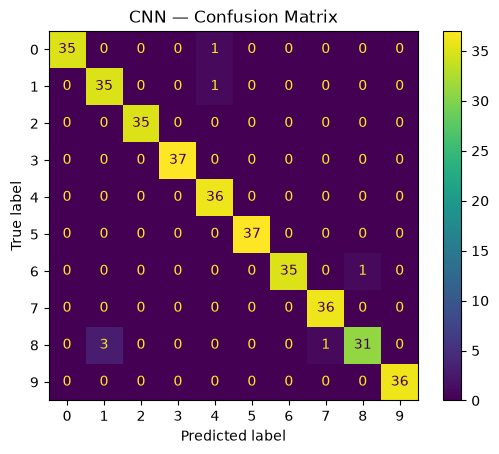

In [36]:
pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("CNN — Confusion Matrix")
plt.show()

In [37]:
# EXERCICES
# 1. Modifier le nombre de filtres.
# 2. Tester kernel_size=5.
# 3. Ajouter un deuxième MaxPooling.